# Flight Price Analysis
### Kazykina Sofya & Gainullina Amina

**Goal:** Analyse the price structure of Indian domestic flights, identify key pricing factors
(class, airline, number of stops, flight duration), and test statistical hypotheses.

## Abstract

This project analyses the price structure of domestic flights in India using a dataset 
of 300,000+ ticket records from Kaggle. We explore how ticket price depends on airline, 
travel class, flight duration, number of stops, and days before departure. The analysis 
includes descriptive statistics, visualisations, and two hypothesis tests. The main 
finding is that travel class is the dominant pricing factor, with Business class tickets 
costing 6–8 times more than Economy on average.

**Contribution:** Sofya Kazykina was responsible for dataset description, descriptive 
statistics, data cleanup, basic plots, detailed overview, and data transformation. 
Aminа Gainullina was responsible for hypothesis testing and discussion. 
The web interface (Streamlit + FastAPI) and abstract were written jointly.

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110


---
## Dataset Description
The dataset contains information about domestic flights in India.

| Column | Type | Description |
|---|---|---|
| `airline` | categorical | Name of the airline |
| `flight` | categorical | Flight code (removed during cleanup) |
| `source_city` | categorical | City of departure |
| `departure_time` | categorical | Time-of-day label for departure |
| `stops` | categorical (text) | Number of stops: zero / one / two |
| `arrival_time` | categorical | Time-of-day label for arrival |
| `destination_city` | categorical | City of arrival |
| `class` | categorical | Ticket class: Economy / Business |
| `duration` | numerical | Flight duration in hours |
| `days_left` | numerical | Days between booking and departure |
| `price` | numerical | Ticket price in INR |

In [2]:
df = pd.read_csv("Clean_Dataset.csv", index_col=0)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
print('Dataset shape:', df.shape)
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

Dataset shape: (300153, 11)
Rows: 300,153  |  Columns: 11


In [4]:
df.dtypes

airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
dtype: object

---
## Data Cleanup

In [5]:
#1. Check for missing values
print('Missing values per column:')
print(df.isna().sum())
print(f'\nTotal missing: {df.isna().sum().sum()}')

Missing values per column:
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Total missing: 0


In [6]:
#2. Check for duplicate rows
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes}')
if n_dupes > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found — dataset is clean.')

Duplicate rows: 0
No duplicates found — dataset is clean.


In [7]:
#3. Convert stops text to integer
print('Unique values in stops:', df['stops'].unique())

stops_map = {'zero': 0, 'one': 1, 'two_or_more': 2}
df['num_stops'] = df['stops'].map(stops_map)

unmapped = df['num_stops'].isna().sum()
print(f'Unmapped stops values: {unmapped}')

if unmapped > 0:
    print('Dropping rows with unmapped stops...')
    df = df.dropna(subset=['num_stops'])

df['num_stops'] = df['num_stops'].astype(int)
print('\nnum_stops value counts:')
print(df['num_stops'].value_counts().sort_index())

Unique values in stops: <ArrowStringArray>
['zero', 'one', 'two_or_more']
Length: 3, dtype: str
Unmapped stops values: 0

num_stops value counts:
num_stops
0     36004
1    250863
2     13286
Name: count, dtype: int64


In [8]:
#4. Drop uninformative columns
cols_to_drop = [c for c in ['stops', 'flight'] if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f'Dropped columns: {cols_to_drop}')

Dropped columns: ['stops', 'flight']


In [9]:
#5. Final verification
print('Final dataset shape:', df.shape)
print('\nColumn dtypes after cleanup:')
print(df.dtypes)
print('\nFirst rows of cleaned dataset:')
df.head()

Final dataset shape: (300153, 10)

Column dtypes after cleanup:
airline                 str
source_city             str
departure_time          str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
num_stops             int64
dtype: object

First rows of cleaned dataset:


,airline,source_city,departure_time,arrival_time,destination_city,class,duration,days_left,price,num_stops
0,SpiceJet,Delhi,Evening,Night,Mumbai,Economy,2.17,1,5953,0
1,SpiceJet,Delhi,Early_Morning,Morning,Mumbai,Economy,2.33,1,5953,0
2,AirAsia,Delhi,Early_Morning,Early_Morning,Mumbai,Economy,2.17,1,5956,0
3,Vistara,Delhi,Morning,Afternoon,Mumbai,Economy,2.25,1,5955,0
4,Vistara,Delhi,Morning,Morning,Mumbai,Economy,2.33,1,5955,0


---
## Descriptive Statistics
Basic statistics for the four numerical fields.

In [10]:
df[['price', 'duration', 'days_left', 'num_stops']].agg(['mean', 'median', 'std']).round(2)

,price,duration,days_left,num_stops
mean,20889.66,12.22,26.00,0.92
median,7425.00,11.25,26.00,1.00
std,22697.77,7.19,13.56,0.40


**Key observations:**
- The mean price (around 20,890 INR) is much higher than the median (around 7,425 INR), indicating a strong right skew driven by expensive Business class tickets.
- The standard deviation of price (around 22,698) is larger than the mean, reflecting extreme variability - Economy and Business fares live in completely different price ranges.
- `days_left` spans 1-49 days, showing a wide mix of last-minute and early bookings.

---
## Plots

- **Histogram** - distribution of ticket prices
- **Scatter plot** - flight duration vs price, coloured by class
- **Horizontal bar chart** - median price by airline
- **Bar chart** - average price by travel class

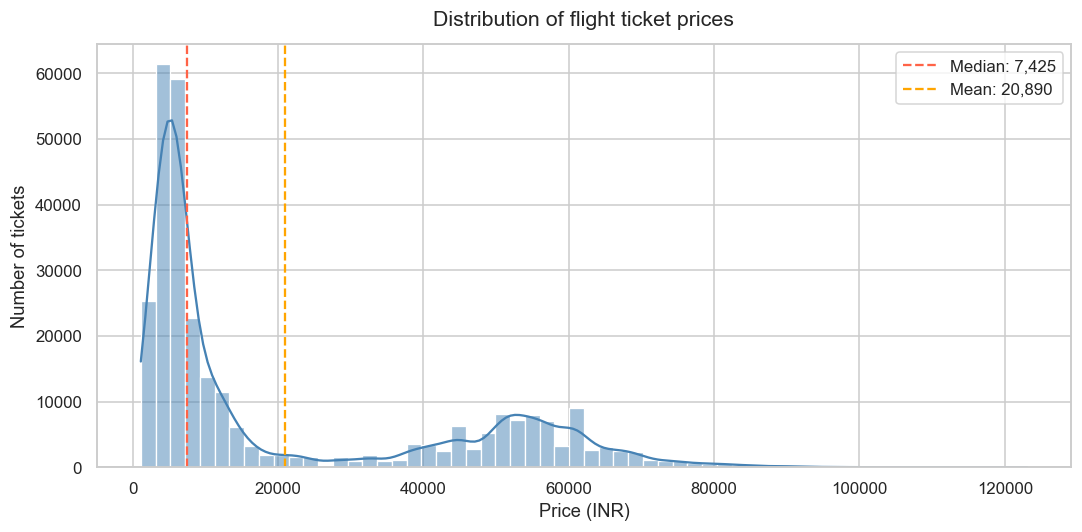

In [11]:
#Plot 1
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df['price'], bins=60, kde=True, color='steelblue', ax=ax)

ax.set_title('Distribution of flight ticket prices', fontsize=14, pad=12)
ax.set_xlabel('Price (INR)', fontsize=12)
ax.set_ylabel('Number of tickets', fontsize=12)
ax.axvline(df['price'].median(), color='tomato', linestyle='--',
           linewidth=1.5, label=f"Median: {df['price'].median():,.0f}")
ax.axvline(df['price'].mean(), color='orange', linestyle='--',
           linewidth=1.5, label=f"Mean: {df['price'].mean():,.0f}")
ax.legend()
plt.tight_layout()
plt.show()

**Price distribution:**
The distribution is strongly right-skewed with a bimodal shape:
a large spike of Economy tickets below 15,000 INR and a smaller cluster of Business tickets
around 60,000-100,000 INR. The mean is far above the median because of the expensive Business class tail.

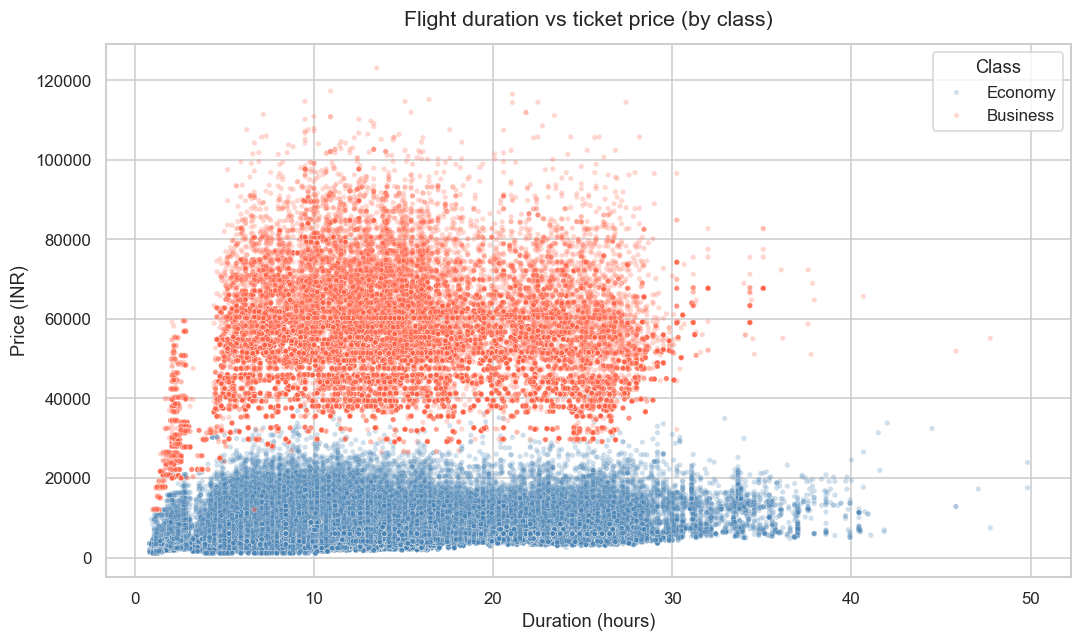

In [12]:
#Plot 2
fig, ax = plt.subplots(figsize=(10, 6))

palette = {'Economy': 'steelblue', 'Business': 'tomato'}
sns.scatterplot(
    data=df, x='duration', y='price',
    hue='class', alpha=0.25, s=12,
    palette=palette, ax=ax
)

ax.set_title('Flight duration vs ticket price (by class)', fontsize=14, pad=12)
ax.set_xlabel('Duration (hours)', fontsize=12)
ax.set_ylabel('Price (INR)', fontsize=12)
ax.legend(title='Class', fontsize=11)
plt.tight_layout()
plt.show()

**Duration vs price:**
Two clearly separated clusters confirm that ticket class is the dominant factor in pricing.
Within Economy (blue), there is a mild positive correlation: longer flights cost more.
Within Business (red), the relationship is weaker - prices are high regardless of duration.
The separation between classes is visible even on short routes.

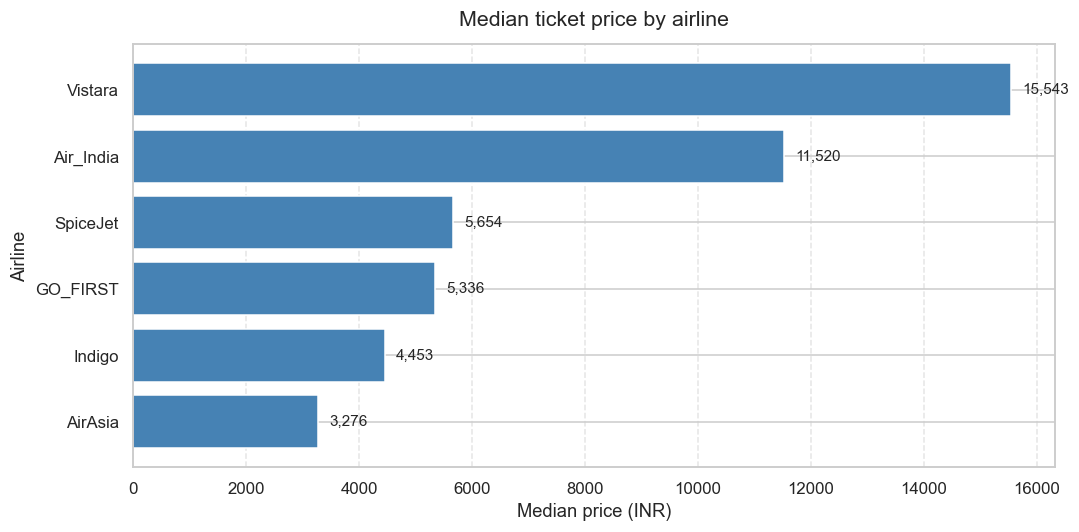

In [13]:
#Plot 3
median_prices = df.groupby('airline')['price'].median().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(median_prices.index, median_prices.values,
               color='steelblue', edgecolor='white')

for bar, val in zip(bars, median_prices.values):
    ax.text(val + 200, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', fontsize=10)

ax.set_title('Median ticket price by airline', fontsize=14, pad=12)
ax.set_xlabel('Median price (INR)', fontsize=12)
ax.set_ylabel('Airline', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Median price by airline:**
There is a clear split between premium carriers (Vistara, Air India) and budget airlines
(SpiceJet, AirAsia, Akasa Air). Vistara's median price is roughly 3-4 times higher than SpiceJet's.

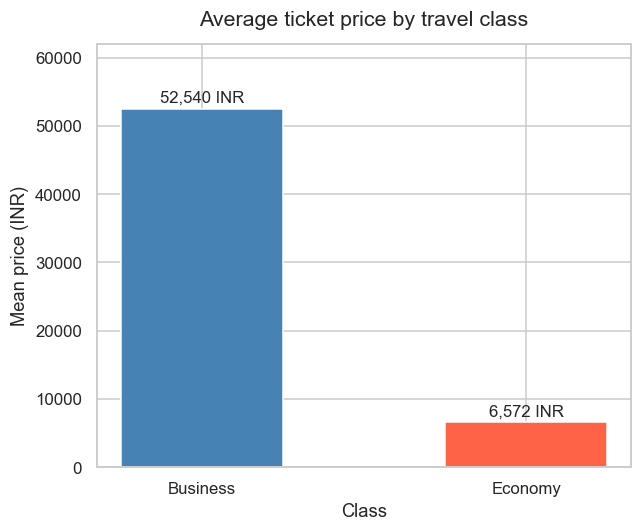

          Mean price  Median price
class                             
Business     52540.0       53164.0
Economy       6572.0        5772.0


In [14]:
#Plot 4
fig, ax = plt.subplots(figsize=(6, 5))

class_stats = df.groupby('class')['price'].agg(['mean', 'median']).round(0)

bars = ax.bar(
    class_stats.index,
    class_stats['mean'],
    color=['steelblue', 'tomato'],
    edgecolor='white', width=0.5
)

for bar, val in zip(bars, class_stats['mean']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f'{val:,.0f} INR',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Average ticket price by travel class', fontsize=14, pad=12)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Mean price (INR)', fontsize=12)
ax.set_ylim(0, class_stats['mean'].max() * 1.18)
plt.tight_layout()
plt.show()

print(class_stats.rename(columns={'mean': 'Mean price', 'median': 'Median price'}))

**Average price by class:**
Business class costs on average roughly 6-8 times more than Economy.
This is the single largest pricing factor in the dataset.
Together with Plot 1, this confirms that any model or analysis of prices
must treat class as the primary grouping variable.

---
## Data Transformation
We add two new columns: `price_per_hour` (cost per hour of flight) 
and `is_early_booking` (1 if booked more than 30 days before departure).

In [15]:
df["price_per_hour"] = df["price"] / df["duration"]
df["is_early_booking"] = (df["days_left"] > 30).astype(int)
df[["price", "duration", "price_per_hour", "days_left", "is_early_booking"]].head()

,price,duration,price_per_hour,days_left,is_early_booking
0,5953,2.17,2743.317972,1,0
1,5953,2.33,2554.935622,1,0
2,5956,2.17,2744.700461,1,0
3,5955,2.25,2646.666667,1,0
4,5955,2.33,2555.793991,1,0


---
## Detailed Overview

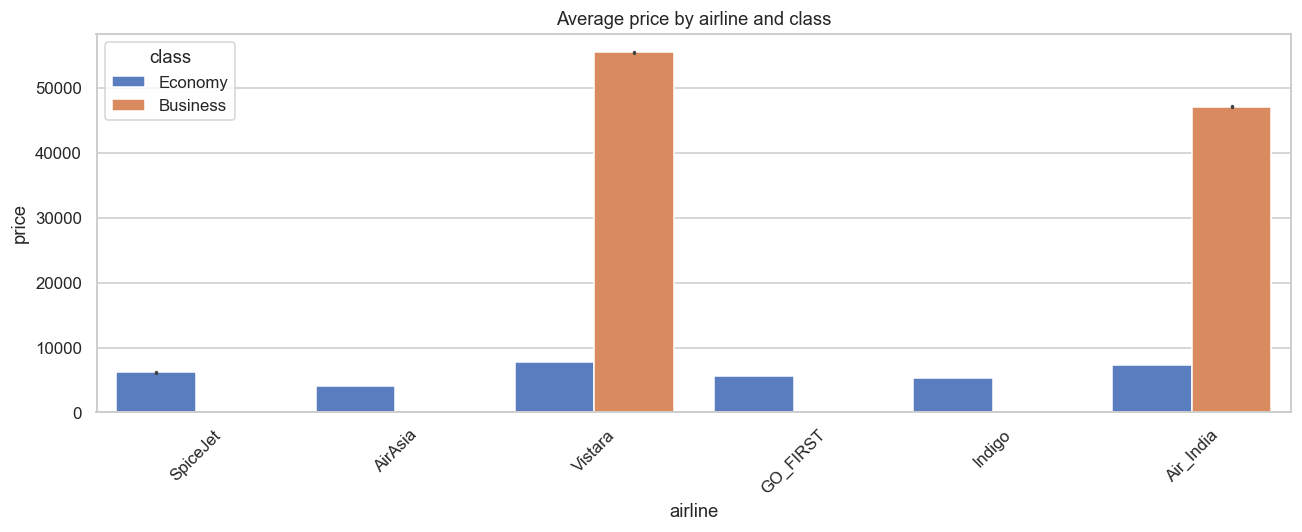

In [16]:
# 1. Average price by airline and class
plt.figure(figsize=(12, 5))
sns.barplot(data=df, x="airline", y="price", hue="class")
plt.title("Average price by airline and class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Business class is significantly more expensive than Economy across all airlines. 
Vistara and Air India show the largest absolute gap between classes.

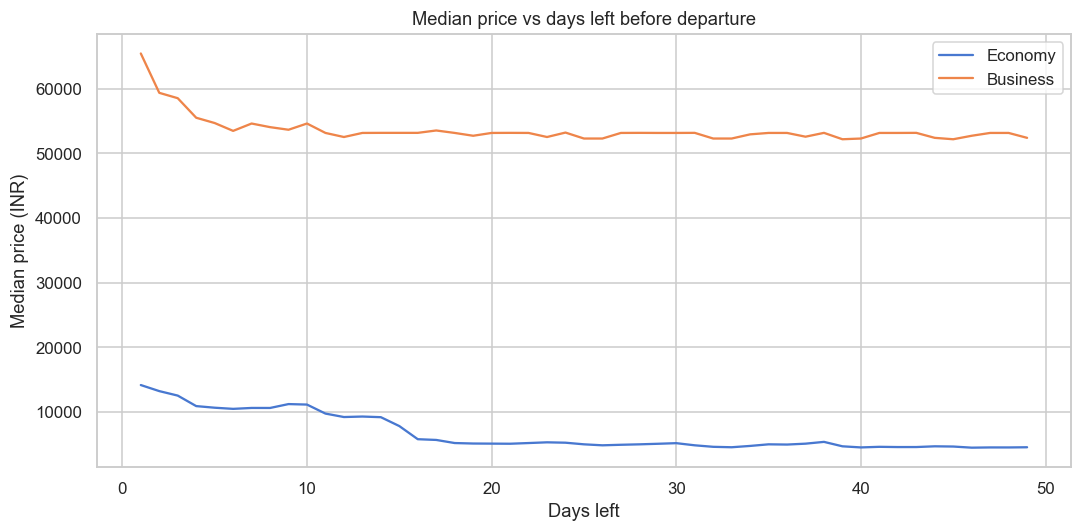

In [17]:
# 2. Median price vs days_left by class
plt.figure(figsize=(10, 5))
for cls in df["class"].unique():
    subset = df[df["class"] == cls].groupby("days_left")["price"].median()
    plt.plot(subset.index, subset.values, label=cls)
plt.title("Median price vs days left before departure")
plt.xlabel("Days left")
plt.ylabel("Median price (INR)")
plt.legend()
plt.tight_layout()
plt.show()

As the departure date approaches, prices rise for both classes. 
The effect is much stronger for Business class tickets,
suggesting that last-minute travellers face higher dynamic pricing pressure.

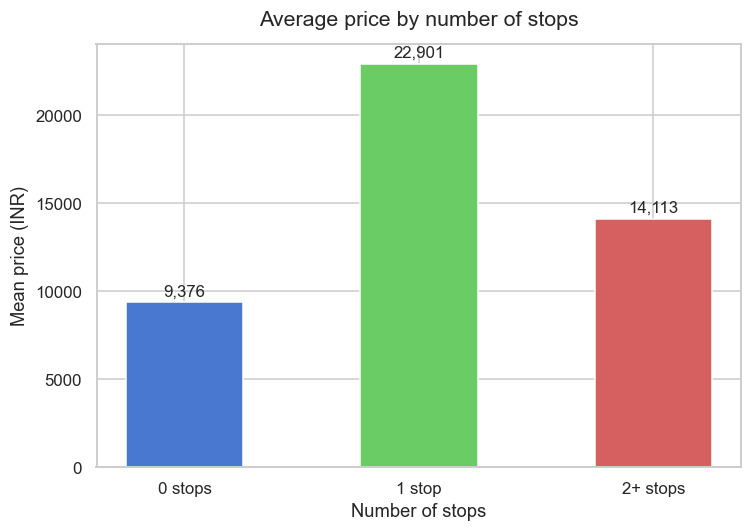

In [ ]:
# 3. Mean price by number of stops
fig, ax = plt.subplots(figsize=(7, 5))

stop_stats = df.groupby('num_stops')['price'].mean().round(0)
bars = ax.bar([0, 1, 2], stop_stats.values,
              color=['#4878CF', '#6ACC65','#D65F5F'], edgecolor='white', width=0.5)

for bar, val in zip(bars, stop_stats.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=11)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['0 stops', '1 stop', '2+ stops'], fontsize=11)
ax.set_title('Average price by number of stops', fontsize=14, pad=12)
ax.set_xlabel('Number of stops', fontsize=12)
ax.set_ylabel('Mean price (INR)', fontsize=12)
plt.tight_layout()
plt.show()

Tickets with more stops are on average more expensive - counterintuitive at first,
but explained by the fact that longer (multi-stop) routes simply cover more distance,
which correlates with higher prices. 

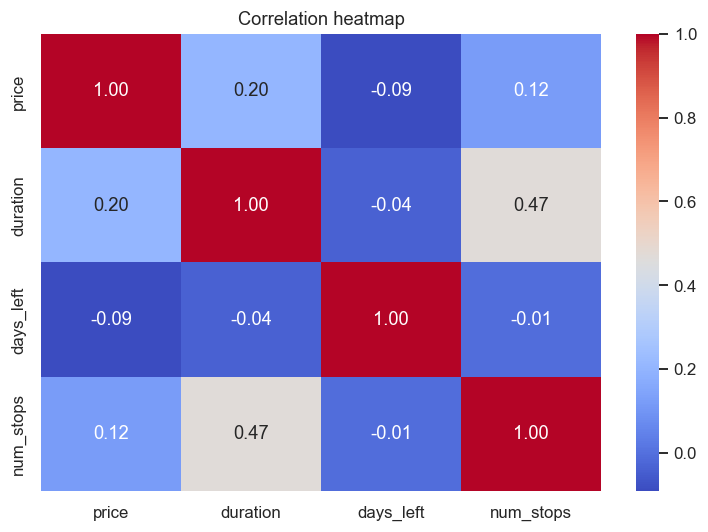

In [19]:
# 4. Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df[["price", "duration", "days_left", "num_stops"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

Price correlates most strongly with `duration` (longer flights → higher price).
`days_left` shows a weak negative correlation with price -
tickets bought closer to departure tend to be slightly more expensive.
`num_stops` has a weak positive correlation with price.

---
## Hypothesis Check

### Hypothesis 1 
**Evening and Night flights have a significantly longer median duration 
than Morning and Late_Night flights, even with the same number of stops.**

We expect that departure time correlates with route type: 
late/early flights cover shorter domestic routes, 
while evening flights tend to be longer international or cross-country routes.

/var/folders/6r/k0tswl5n0ldg7jqdg_4c2tbh0000gn/T/ipykernel_7702/2061792643.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=one_stop, x="departure_time", y="duration",


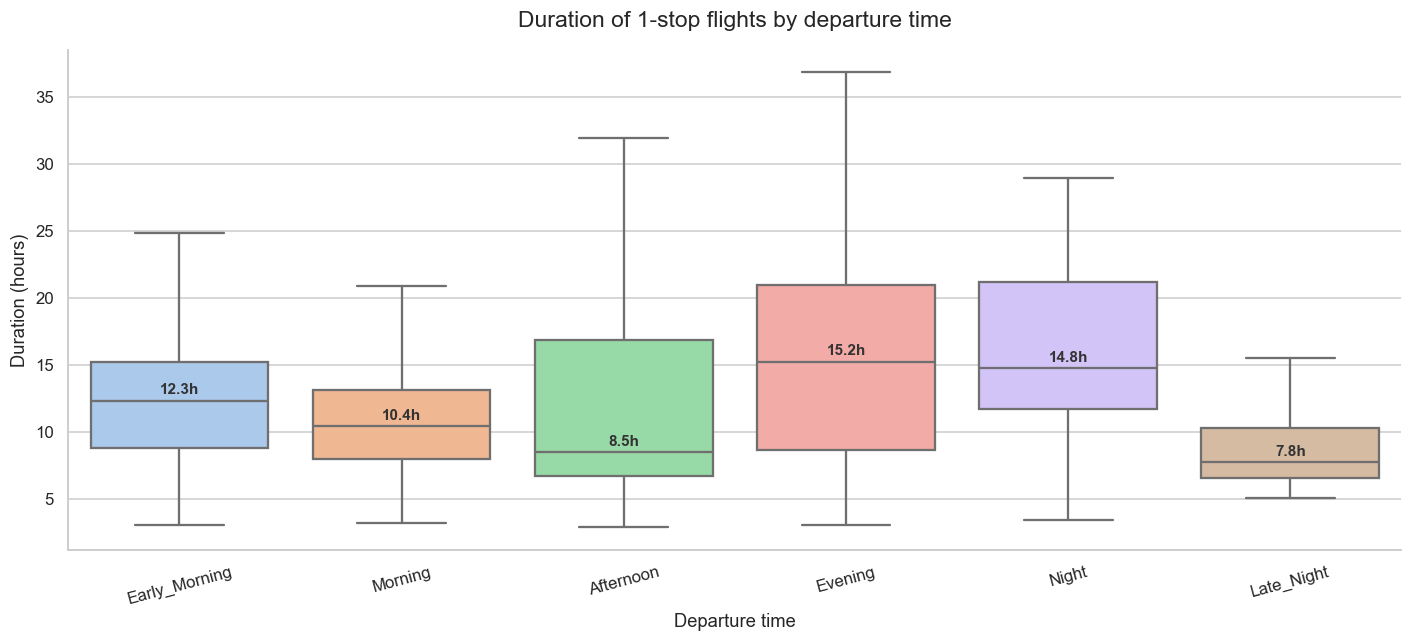

Median duration by departure time:
departure_time
Late_Night        7.75
Afternoon         8.50
Morning          10.42
Early_Morning    12.33
Night            14.75
Evening          15.25
Name: duration, dtype: float64


In [20]:
time_order = ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"]
one_stop = df[df["num_stops"] == 1]

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=one_stop, x="departure_time", y="duration",
            order=time_order, palette="pastel",
            showfliers=False, linewidth=1.5, ax=ax)

medians = one_stop.groupby("departure_time")["duration"].median()
for i, time in enumerate(time_order):
    ax.text(i, medians[time] + 0.3, f'{medians[time]:.1f}h',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

ax.set_title("Duration of 1-stop flights by departure time", fontsize=15, pad=15)
ax.set_xlabel("Departure time", fontsize=12)
ax.set_ylabel("Duration (hours)", fontsize=12)
ax.tick_params(axis='x', rotation=15)
sns.despine()
plt.tight_layout()
plt.show()

print("Median duration by departure time:")
print(one_stop.groupby("departure_time")["duration"].median().sort_values())

The hypothesis is partially confirmed. Evening (15.2h) and Night (14.8h) 
flights indeed have the longest durations. Late_Night (7.8h) and Morning (10.4h) 
are the shortest as expected. However, Afternoon (8.5h) is also short, contradicting a simple "later = longer" pattern. The result suggests that 
Evening and Night slots are systematically used for longer routes.

### Hypothesis 2
**Price per hour of flight is lower for the most frequent airlines 
(IndiGo, Air India) compared to other airlines.**

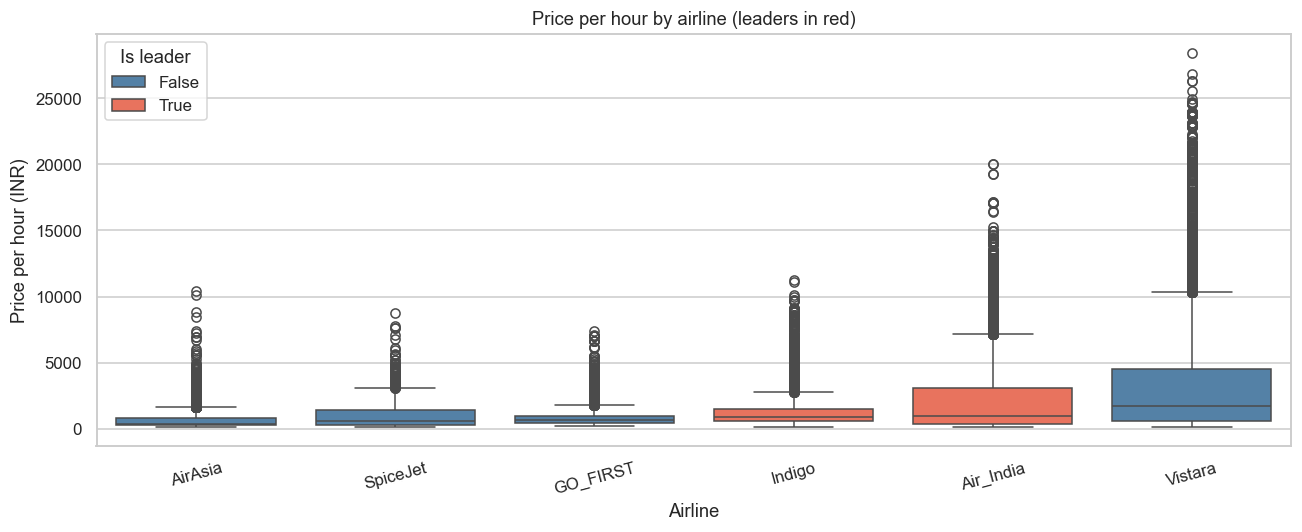

Median price per hour — leaders vs others:
is_leader
False    1007.222787
True      941.283764
Name: price_per_hour, dtype: float64


In [21]:
df["is_leader"] = df["airline"].isin(["Indigo", "Air_India"])

plt.figure(figsize=(12, 5))
order = df.groupby("airline")["price_per_hour"].median().sort_values().index
sns.boxplot(data=df, x="airline", y="price_per_hour", order=order,
            hue="is_leader", dodge=False,
            palette={True: "tomato", False: "steelblue"})
plt.title("Price per hour by airline (leaders in red)")
plt.xlabel("Airline")
plt.ylabel("Price per hour (INR)")
plt.xticks(rotation=15)
plt.legend(title="Is leader")
plt.tight_layout()
plt.show()

print("Median price per hour — leaders vs others:")
print(df.groupby("is_leader")["price_per_hour"].median())

The hypothesis is not confirmed. Air India (red) shows a higher median 
price per hour than most budget airlines, not lower. Indigo has a low 
median price per hour, consistent with its budget positioning, but Air India 
behaves more like a premium carrier. The hypothesis holds for Indigo but 
not for Air India.

---
## Discussion

### Dataset overview

The dataset contains information about domestic flights in India across 6 cities and 6 airlines, covering both Economy and Business class tickets. The data required very little cleaning - no missing values or duplicate rows were found. The only structural change needed was converting the stops column from text labels (zero / one / two) to numeric values (0 / 1 / 2), allowing numerical comparisons. Two additional columns were created during transformation: `price_per_hour` (ticket price divided by flight duration) and is_early_booking (1 if the ticket was booked more than 30 days before departure).

### Pricing patterns

The most noticeable feature of this dataset is the large price variation across ticket classes. The mean price (about 20,890 INR) is nearly three times higher than the median (about 7,425 INR), and the standard deviation (about 22,698 INR) is even higher than the mean itself - both figures suggest a distribution strongly affected by expensive Business class fares. The price histogram shows this clearly: there is a large cluster of Economy tickets below 15,000 INR and a separate, smaller cluster of Business tickets concentrated between 60,000 and 100,000 INR. The two groups form a clearly bimodal distribution with very little overlap.

The scatter plot of duration vs price also confirms this separation: Economy and Business tickets form two distinct groups regardless of flight length. Within the Economy group, there is a clear upward trend - as duration increases, price also increases - while the Business group shows a weaker and more scattered pattern, with prices remaining high even on short routes.

### Factors associated with price

Among the numerical variables, flight duration shows the strongest positive correlation with price (visible in both the scatter plot and the correlation heatmap). The number of stops is positively correlated with both duration and price: tickets with two stops have a higher average price than direct flights, which is consistent with the observation that flights with multiple stops tend to cover longer total distances. The days_left variable shows a weak negative correlation with price - tickets purchased closer to the departure date are, on average, slightly more expensive, and this effect is clearly stronger for Business class in the line plot of median price vs days left.

Among the categorical variables, airline is an important differentiator. The horizontal bar chart shows a clear ranking: Vistara's median price is approximately 3-4 times higher than SpiceJet's, with Air India positioned at the premium end and AirAsia and SpiceJet at the budget end. The grouped bar chart (Detailed Overview) shows that this difference between airlines is mainly driven by Business class fares: premium carriers charge significantly more for Business seats, while budget airlines show a smaller Economy-to-Business gap. An interesting observation regarding flight frequency: Vistara has the highest number of flights in the dataset despite being one of the most expensive airlines, while SpiceJet has the fewest flights despite its budget pricing. This suggests that flight frequency is driven more by route coverage and fleet size than by ticket price alone.

### Hypothesis results

**Hypothesis 1** stated that Evening and Night flights have a significantly longer median duration than Morning and Late_Night flights, even when controlling for the number of stops. This was tested using a box plot of flight duration grouped by departure time, restricted to one-stop flights. The result partially confirmed the hypothesis: Evening flights recorded the longest median duration (15.2 h) and Night flights the second longest (14.8 h), while Late_Night (7.8 h) and Morning (10.4 h) were among the shortest. However, Afternoon flights (8.5 h) also showed a short median duration, which means the pattern is not simply "later departure = longer flight." The hypothesis is therefore partially confirmed — the Evening and Night time slots are associated with longer routes, but the pattern does not apply equally across all time periods.

**Hypothesis 2** stated that the most frequent airlines (IndiGo and Air India) have a lower median price per hour compared to other airlines. This was tested using a box plot of `price_per_hour` grouped by airline, with the two target airlines highlighted. The hypothesis is not confirmed: Air India's median price per hour is higher than that of most other carriers, placing it in the premium segment rather than the budget segment. IndiGo does show a low price per hour consistent with its budget positioning, so the hypothesis holds for IndiGo individually but not for Air India. Therefore, the overall claim is false.

### Overall summary

Across all parts of this analysis, ticket class consistently appears to be the most important variable associated with price. The Economy and Business segments behave like two separate markets: they differ in price levels, in the strength of the duration-price relationship, in how prices change with the number of days left before departure, and in the size of the differences across airlines. Among the remaining factors, flight duration and airline are the next most informative variables, followed by the number of stops and booking timing. The two hypotheses tested in this project produced mixed results - one was partially confirmed, while the other was rejected.